# Notebook 01 — Exploratory Data Analysis

Dataset: **MovieLens Small** — 100,836 ratings, 610 users, 9,742 movies  
Files used: `data/raw/ratings.csv`, `data/raw/movies.csv`, `data/raw/tags.csv`

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = Path('../data/raw')

## 1. Load Data

In [2]:
ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
movies  = pd.read_csv(DATA_DIR / 'movies.csv')
tags    = pd.read_csv(DATA_DIR / 'tags.csv')

n_users   = ratings.userId.nunique()
n_movies  = ratings.movieId.nunique()
n_ratings = len(ratings)
sparsity  = 1 - n_ratings / (n_users * n_movies)

print(f'Users   : {n_users:,}')
print(f'Movies  : {n_movies:,}')
print(f'Ratings : {n_ratings:,}')
print(f'Sparsity: {sparsity:.4%}')
ratings.head()

Users   : 610
Movies  : 9,724
Ratings : 100,836
Sparsity: 98.3000%


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2. Rating Distribution

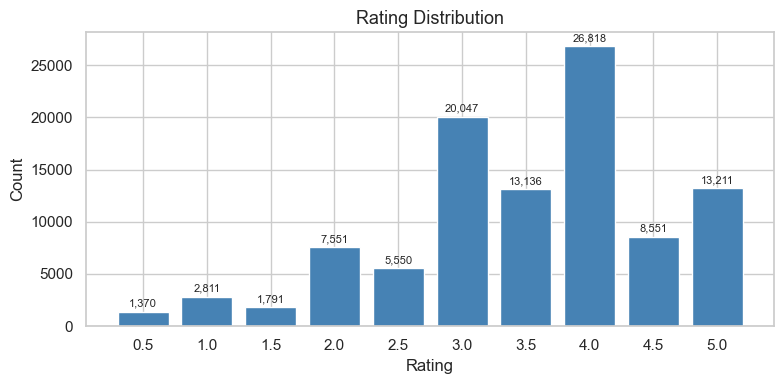

Mean rating: 3.502 | Median: 3.5


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
rating_counts = ratings.rating.value_counts().sort_index()
ax.bar(rating_counts.index.astype(str), rating_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Rating Distribution', fontsize=13)
ax.set_xlabel('Rating'); ax.set_ylabel('Count')
for bar, val in zip(ax.patches, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()
print(f'Mean rating: {ratings.rating.mean():.3f} | Median: {ratings.rating.median()}')

## 3. Ratings per User (Long-tail)

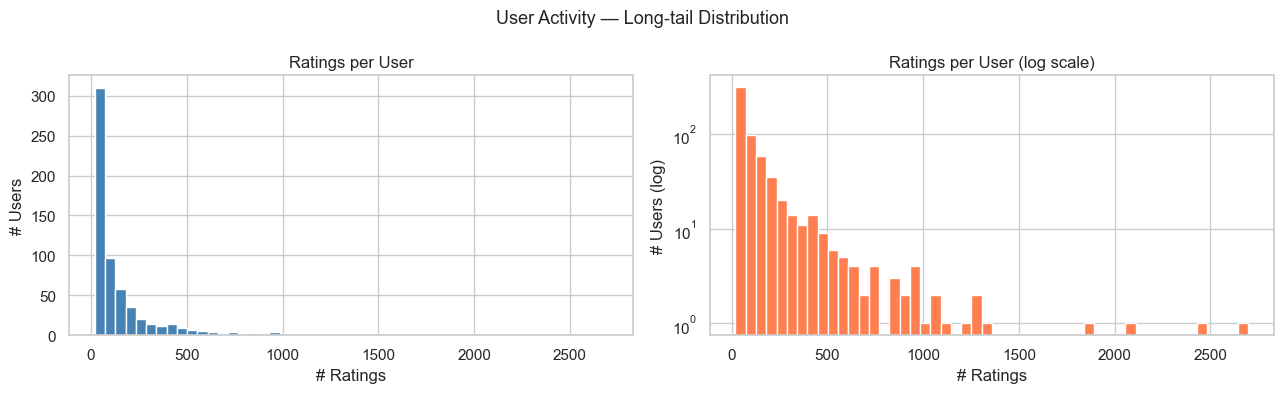

Min: 20 | Max: 2698 | Mean: 165.3 | Median: 70.5
Users with < 20 ratings: 0 (0.0%)


In [4]:
ratings_per_user = ratings.groupby('userId').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Ratings per User'); axes[0].set_xlabel('# Ratings'); axes[0].set_ylabel('# Users')

axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='white', log=True)
axes[1].set_title('Ratings per User (log scale)'); axes[1].set_xlabel('# Ratings'); axes[1].set_ylabel('# Users (log)')

plt.suptitle('User Activity — Long-tail Distribution', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Min: {ratings_per_user.min()} | Max: {ratings_per_user.max()} | Mean: {ratings_per_user.mean():.1f} | Median: {ratings_per_user.median()}')
print(f'Users with < 20 ratings: {(ratings_per_user < 20).sum()} ({(ratings_per_user < 20).mean():.1%})')

## 4. Ratings per Movie (Long-tail)

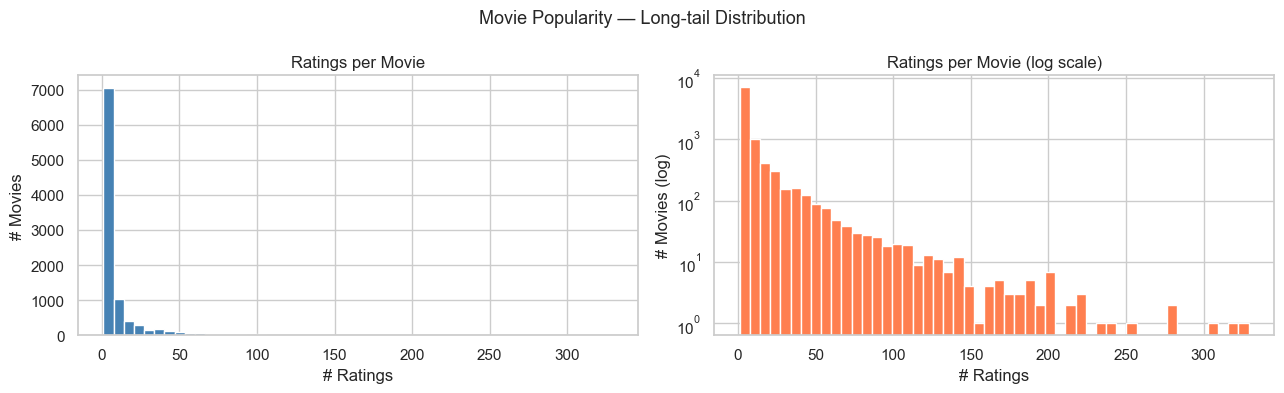

Min: 1 | Max: 329 | Mean: 10.4 | Median: 3.0
Movies with < 5 ratings: 6074 (62.5%)


In [5]:
ratings_per_movie = ratings.groupby('movieId').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ratings_per_movie, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Ratings per Movie'); axes[0].set_xlabel('# Ratings'); axes[0].set_ylabel('# Movies')

axes[1].hist(ratings_per_movie, bins=50, color='coral', edgecolor='white', log=True)
axes[1].set_title('Ratings per Movie (log scale)'); axes[1].set_xlabel('# Ratings'); axes[1].set_ylabel('# Movies (log)')

plt.suptitle('Movie Popularity — Long-tail Distribution', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Min: {ratings_per_movie.min()} | Max: {ratings_per_movie.max()} | Mean: {ratings_per_movie.mean():.1f} | Median: {ratings_per_movie.median()}')
print(f'Movies with < 5 ratings: {(ratings_per_movie < 5).sum()} ({(ratings_per_movie < 5).mean():.1%})')

## 5. Genre Frequency

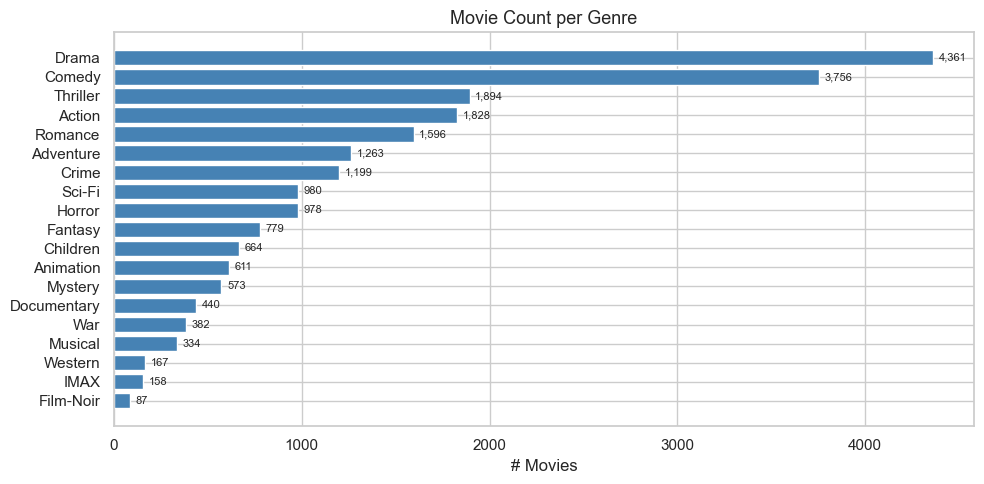

In [6]:
genre_counts = (
    movies.genres.str.split('|')
    .explode()
    .pipe(lambda s: s[s != '(no genres listed)'])
    .value_counts()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue')
ax.set_title('Movie Count per Genre', fontsize=13)
ax.set_xlabel('# Movies')
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

## 6. Genre Co-occurrence Heatmap

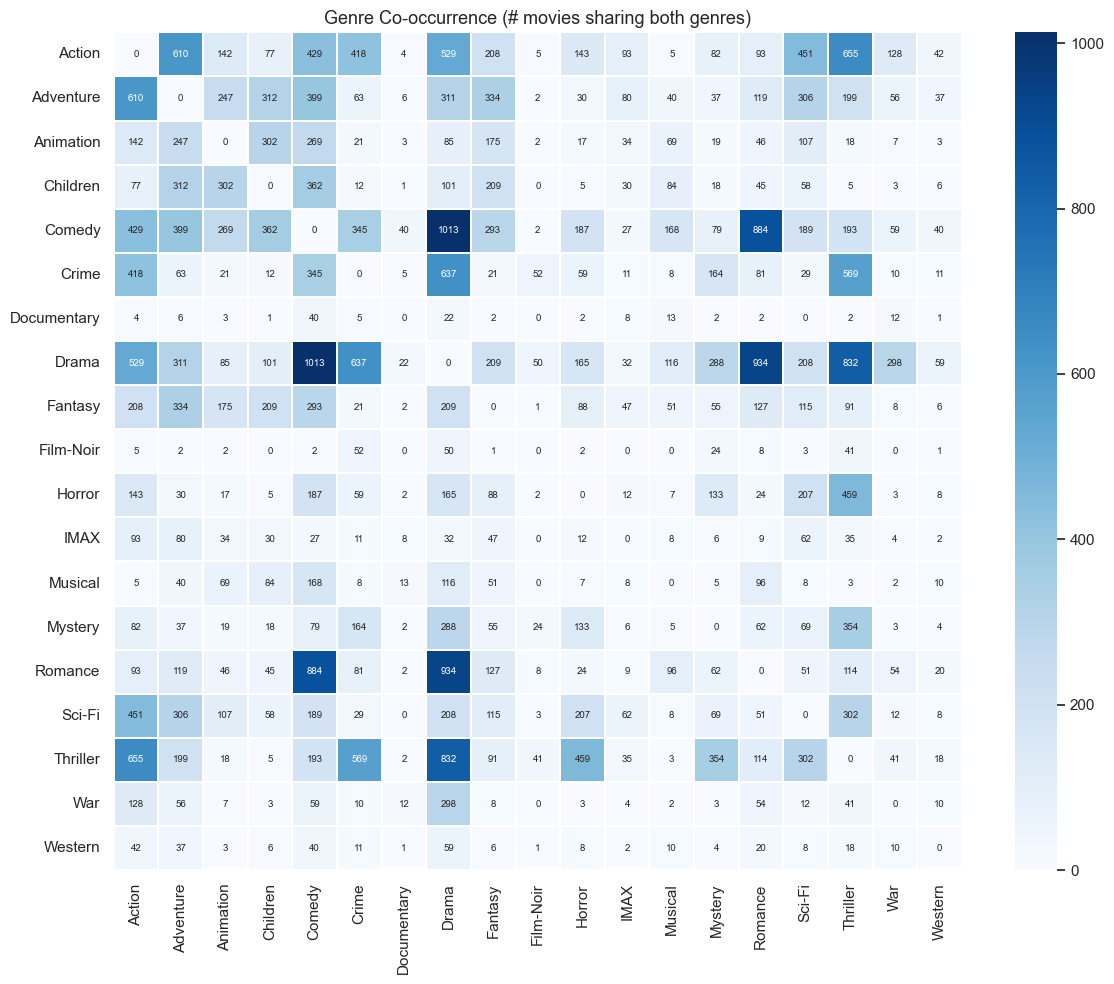

In [7]:
ALL_GENRES = sorted(g for g in movies.genres.str.split('|').explode().unique() if g != '(no genres listed)')
for g in ALL_GENRES:
    movies[g] = movies.genres.str.contains(g, regex=False).astype(int)

cooccur = movies[ALL_GENRES].T.dot(movies[ALL_GENRES])
np.fill_diagonal(cooccur.values, 0)  # zero diagonal for readability

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cooccur, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Genre Co-occurrence (# movies sharing both genres)', fontsize=13)
plt.tight_layout(); plt.show()

## 7. Average Rating per Genre

/var/folders/8h/np3nd9b978dbk3rypvf8xnv00000gn/T/ipykernel_75201/809796004.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ALL_GENRES, patch_artist=True, notch=False)


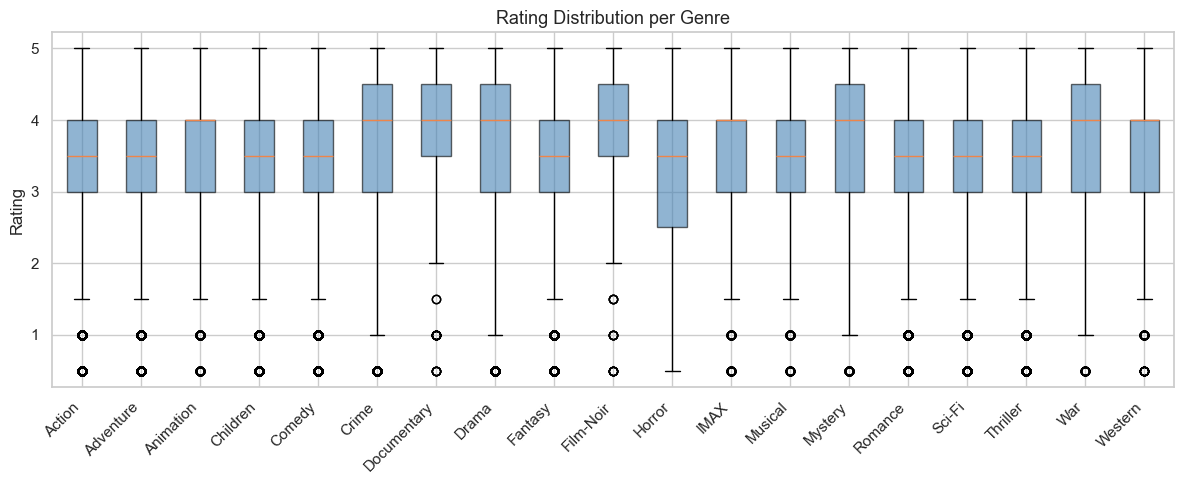

In [8]:
merged = ratings.merge(movies[['movieId'] + ALL_GENRES], on='movieId', how='left')

genre_ratings = {}
for g in ALL_GENRES:
    genre_ratings[g] = merged.loc[merged[g] == 1, 'rating'].values

fig, ax = plt.subplots(figsize=(12, 5))
data = [genre_ratings[g] for g in ALL_GENRES]
bp = ax.boxplot(data, labels=ALL_GENRES, patch_artist=True, notch=False)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue'); patch.set_alpha(0.6)
ax.set_title('Rating Distribution per Genre', fontsize=13)
ax.set_ylabel('Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 8. Ratings Over Time

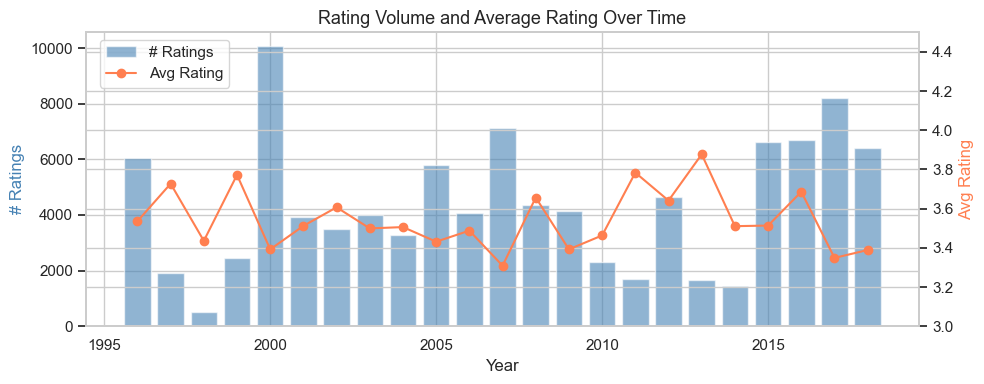

In [9]:
ratings['year'] = pd.to_datetime(ratings['timestamp'], unit='s').dt.year
yearly = ratings.groupby('year').agg(n_ratings=('rating','count'), avg_rating=('rating','mean')).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(yearly.year, yearly.n_ratings, color='steelblue', alpha=0.6, label='# Ratings')
ax2.plot(yearly.year, yearly.avg_rating, color='coral', marker='o', label='Avg Rating')
ax1.set_xlabel('Year'); ax1.set_ylabel('# Ratings', color='steelblue')
ax2.set_ylabel('Avg Rating', color='coral')
ax2.set_ylim(3.0, 4.5)
ax1.set_title('Rating Volume and Average Rating Over Time', fontsize=13)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout(); plt.show()

## 9. Tags Analysis

Total tags      : 3,683
Unique tags     : 1,589
Movies with tags: 1,572 / 9,724 (16.2%)


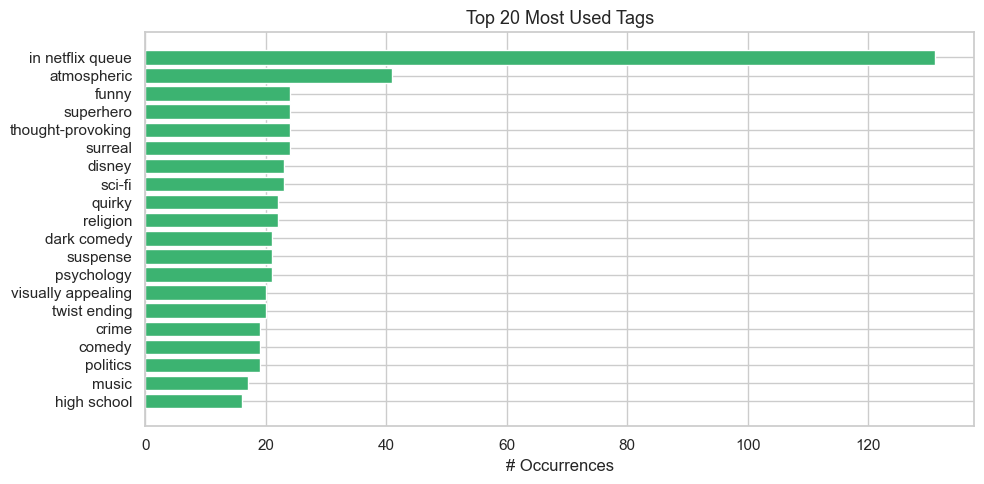

In [10]:
print(f'Total tags      : {len(tags):,}')
print(f'Unique tags     : {tags.tag.nunique():,}')
print(f'Movies with tags: {tags.movieId.nunique():,} / {n_movies:,} ({tags.movieId.nunique()/n_movies:.1%})')

top_tags = tags.tag.str.lower().value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_tags.index[::-1], top_tags.values[::-1], color='mediumseagreen')
ax.set_title('Top 20 Most Used Tags', fontsize=13)
ax.set_xlabel('# Occurrences')
plt.tight_layout(); plt.show()

## 10. Summary Statistics

In [11]:
summary = pd.DataFrame({
    'Metric': [
        'Users', 'Movies (rated)', 'Movies (catalog)', 'Ratings',
        'Sparsity', 'Mean Rating', 'Median Rating',
        'Mean Ratings/User', 'Mean Ratings/Movie',
        'Movies with Tags', 'Unique Tags'
    ],
    'Value': [
        f'{n_users:,}',
        f'{n_movies:,}',
        f'{len(movies):,}',
        f'{n_ratings:,}',
        f'{sparsity:.4%}',
        f'{ratings.rating.mean():.3f}',
        f'{ratings.rating.median()}',
        f'{ratings_per_user.mean():.1f}',
        f'{ratings_per_movie.mean():.1f}',
        f'{tags.movieId.nunique():,}',
        f'{tags.tag.nunique():,}',
    ]
})
display(summary)

,Metric,Value
0,Users,610
1,Movies (rated),"9,724"
2,Movies (catalog),"9,742"
3,Ratings,"100,836"
4,Sparsity,98.3000%
5,Mean Rating,3.502
6,Median Rating,3.5
7,Mean Ratings/User,165.3
8,Mean Ratings/Movie,10.4
9,Movies with Tags,"1,572"
